In [8]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import dataframe_image as dfi

sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

PLOT_DIR = "../notebooks/plots/comparison/"
os.makedirs(PLOT_DIR, exist_ok=True)

MODELS = ["distilbert", "xlm_roberta", "muril"]
DISPLAY_NAMES = {
    "distilbert": "DistilBERT",
    "xlm_roberta": "XLM-RoBERTa",
    "muril": "MuRIL"
}
MODEL_COLORS = {
    "distilbert": "#E74C3C",
    "xlm_roberta": "#3498DB",
    "muril": "#2ECC71"
}

PATHS = {
    "distilbert": {
        "results": "../checkpoints/distilbert_baseline/results.json",
        "state": "../checkpoints/distilbert_baseline/checkpoint-12935/trainer_state.json"
    },
    "xlm_roberta": {
        "results": "../checkpoints/xlm_roberta/results.json",
        "state": "../checkpoints/xlm_roberta/checkpoint-15522/trainer_state.json"
    },
    "muril": {
        "results": "../checkpoints/muril_base/results.json",
        "state": "../checkpoints/muril_base/checkpoint-25870/trainer_state.json"
    }
}

results_dict = {}
states_dict = {}

# Load live files from disk directly
for m in MODELS:
    with open(PATHS[m]["results"], "r") as f:
        results_dict[m] = json.load(f)
        
    with open(PATHS[m]["state"], "r") as f:
        states_dict[m] = json.load(f)

# Global B&W safe configuration updates
matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": matplotlib.cycler(color=["#111111","#555555","#999999","#CCCCCC"]),
    "hatch.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

In [13]:
metrics_data = []
for m in MODELS:
    res = results_dict[m]
    
    # Safe structure extraction from live disk files
    p_cf1 = res.get("per_class_f1", {})
    if isinstance(p_cf1, dict):
        f1_hate = p_cf1.get("hate", p_cf1.get("0", 0.0))
        f1_off  = p_cf1.get("offensive", p_cf1.get("1", 0.0))
        f1_norm = p_cf1.get("normal", p_cf1.get("2", 0.0))
    else:
        f1_hate = p_cf1[0] if len(p_cf1) > 0 else 0.0
        f1_off  = p_cf1[1] if len(p_cf1) > 1 else 0.0
        f1_norm = p_cf1[2] if len(p_cf1) > 2 else 0.0

    # Extract accuracy from standalone key or parse from the report text string
    acc = res.get("accuracy", None)
    if acc is None and "report" in res:
        for line in res["report"].split("\n"):
            if "accuracy" in line:
                parts = line.split()
                # Handles picking out value safely whether string index shifts
                acc = float(parts[-2]) if parts[-2].replace('.','',1).isdigit() else float(parts[-1])
    if acc is None:
        acc = 0.0
        
    metrics_data.append({
        "Model": DISPLAY_NAMES[m],
        "Macro-F1": res.get("macro_f1", 0.0),
        "Weighted-F1": res.get("weighted_f1", 0.0),
        "Accuracy": acc,
        "Hate F1": f1_hate,
        "Offensive F1": f1_off,
        "Normal F1": f1_norm
    })

df_metrics = pd.DataFrame(metrics_data).set_index("Model")

# styled_df = df_metrics.style.highlight_max(axis=0, color='yellow')
dfi.export(df_metrics, 'models_comparison.png',table_conversion='matplotlib')
print(df_metrics)

             Macro-F1  Weighted-F1  Accuracy  Hate F1  Offensive F1  Normal F1
Model                                                                         
DistilBERT     0.7828       0.8358    0.8319   0.6426        0.8148     0.8911
XLM-RoBERTa    0.7867       0.8401    0.8341   0.6438        0.8228     0.8935
MuRIL          0.7971       0.8440    0.8411   0.6731        0.8246     0.8936


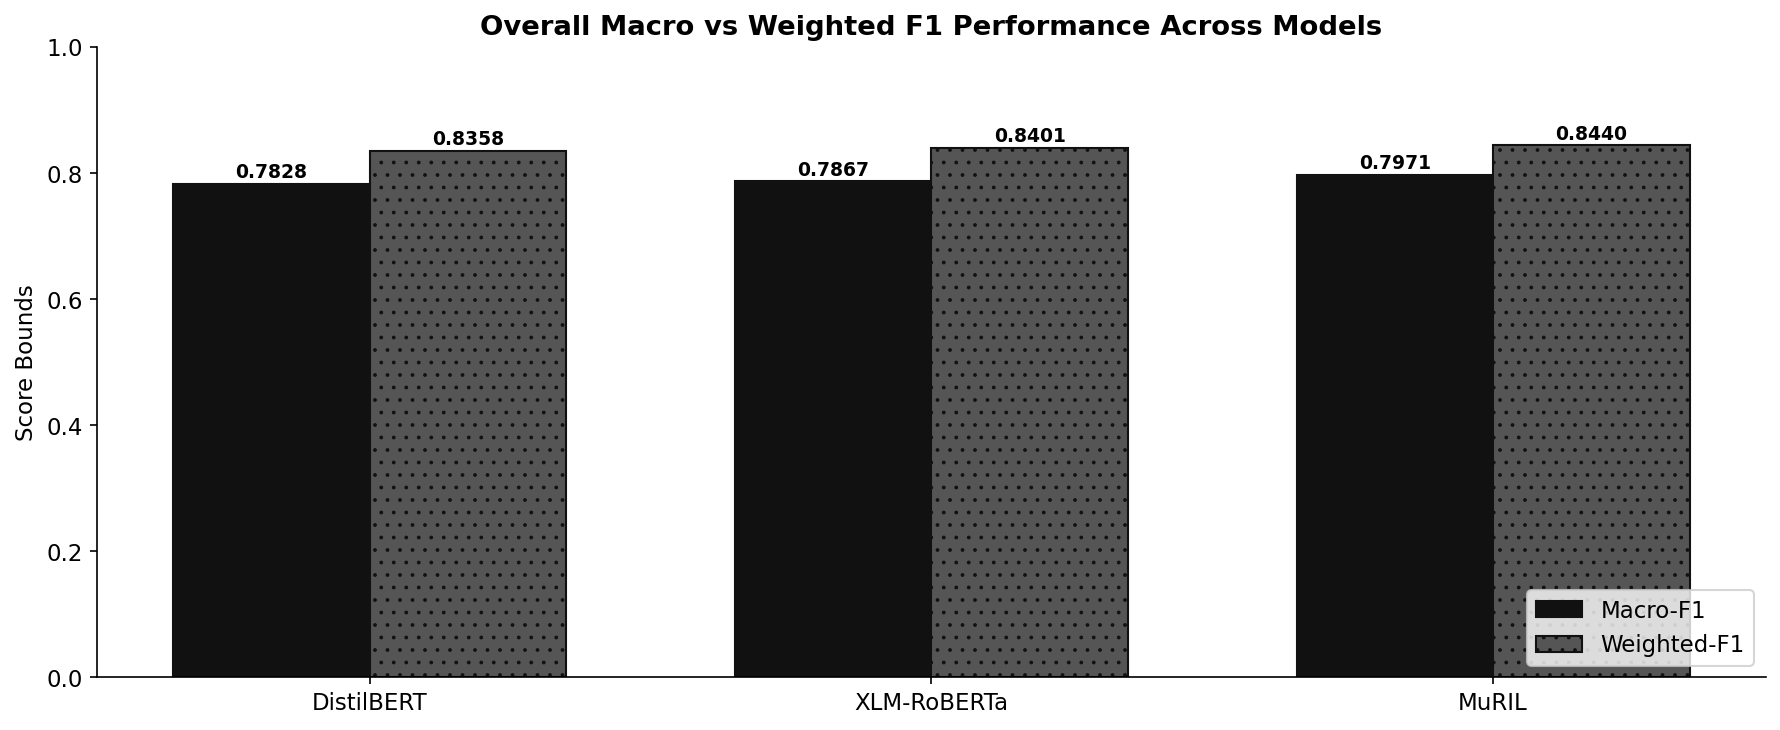

In [16]:
plt.figure(figsize=(12, 5))

x = np.arange(len(MODELS))
width = 0.35

macro_vals = [df_metrics.loc[DISPLAY_NAMES[m], "Macro-F1"] for m in MODELS]
weighted_vals = [df_metrics.loc[DISPLAY_NAMES[m], "Weighted-F1"] for m in MODELS]

# Multi-bar structural generation with grayscale compatibility logic via hatch variances
bars1 = plt.bar(x - width/2, macro_vals, width, label="Macro-F1", edgecolor="#111111", hatch="//")
bars2 = plt.bar(x + width/2, weighted_vals, width, label="Weighted-F1", edgecolor="#111111", hatch="..")

# Value label insertions
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.title("Overall Macro vs Weighted F1 Performance Across Models", fontweight="bold")
plt.xticks(x, [DISPLAY_NAMES[m] for m in MODELS])
plt.ylabel("Score Bounds")
plt.ylim(0, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}macro_weighted_comparison.png")
plt.show()

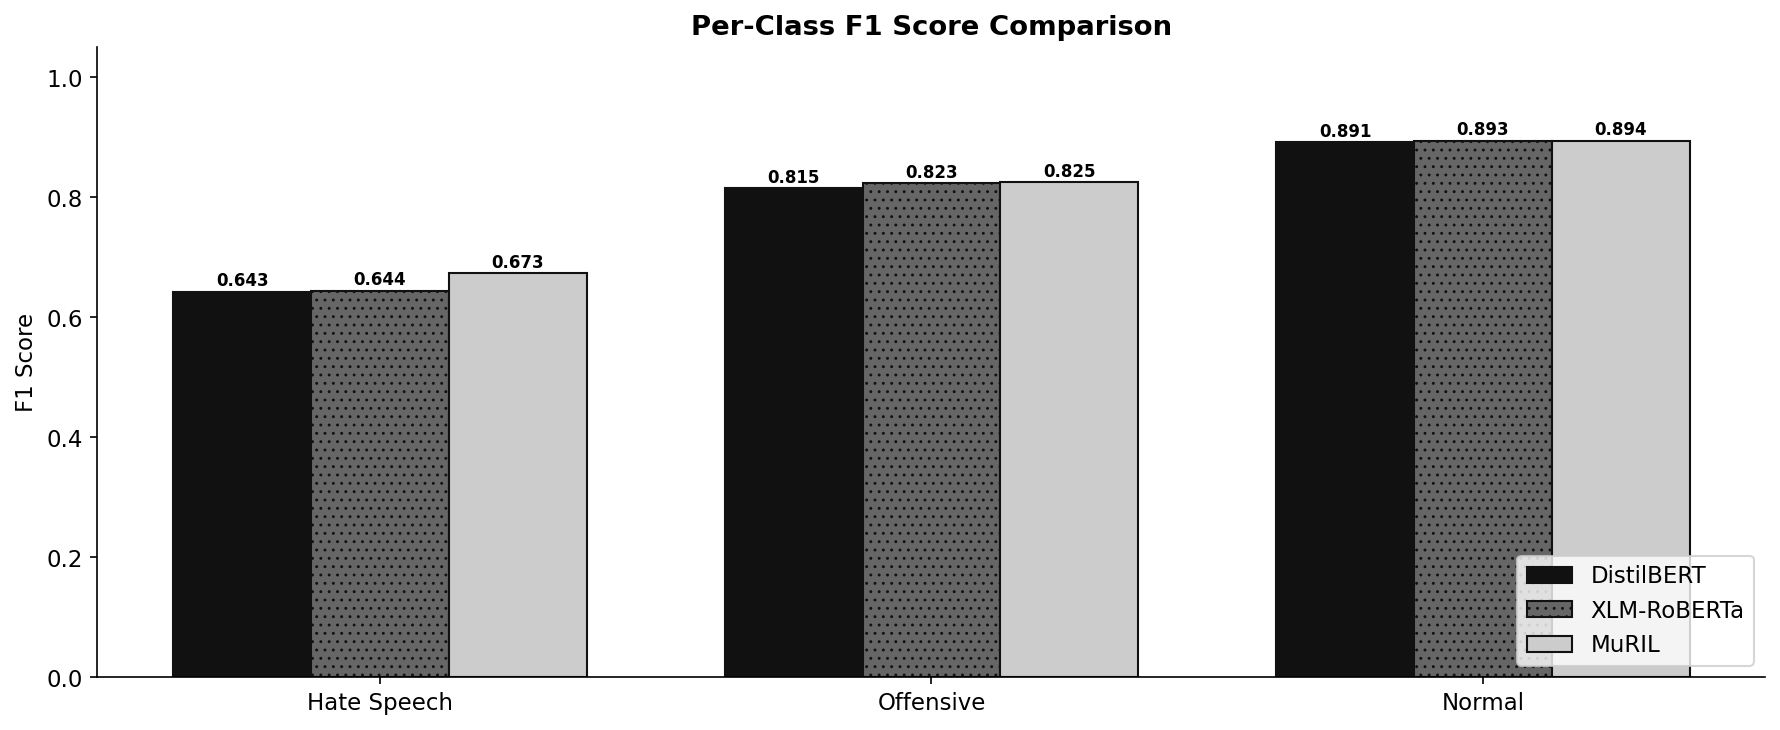

In [19]:
plt.figure(figsize=(12, 5))

classes = ["Hate F1", "Offensive F1", "Normal F1"]
x = np.arange(len(classes))
width = 0.25

# Generate grouped charts mapping model variations per class category
for idx, m in enumerate(MODELS):
    vals = [df_metrics.loc[DISPLAY_NAMES[m], c] for c in classes]
    offset = (idx - 1) * width
    
    # Custom assign hatch details per model baseline to ensure print readiness
    hatch_style = "///" if idx == 0 else ("..." if idx == 1 else "")
    bars = plt.bar(x + offset, vals, width, label=DISPLAY_NAMES[m], 
                   edgecolor="#111111", hatch=hatch_style, color=["#111111", "#666666", "#CCCCCC"][idx])
    
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}", ha="center", fontsize=8, fontweight="bold")

plt.title("Per-Class F1 Score Comparison", fontweight="bold")
plt.xticks(x, ["Hate Speech", "Offensive", "Normal"])
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}per_class_comparison.png")
plt.show()

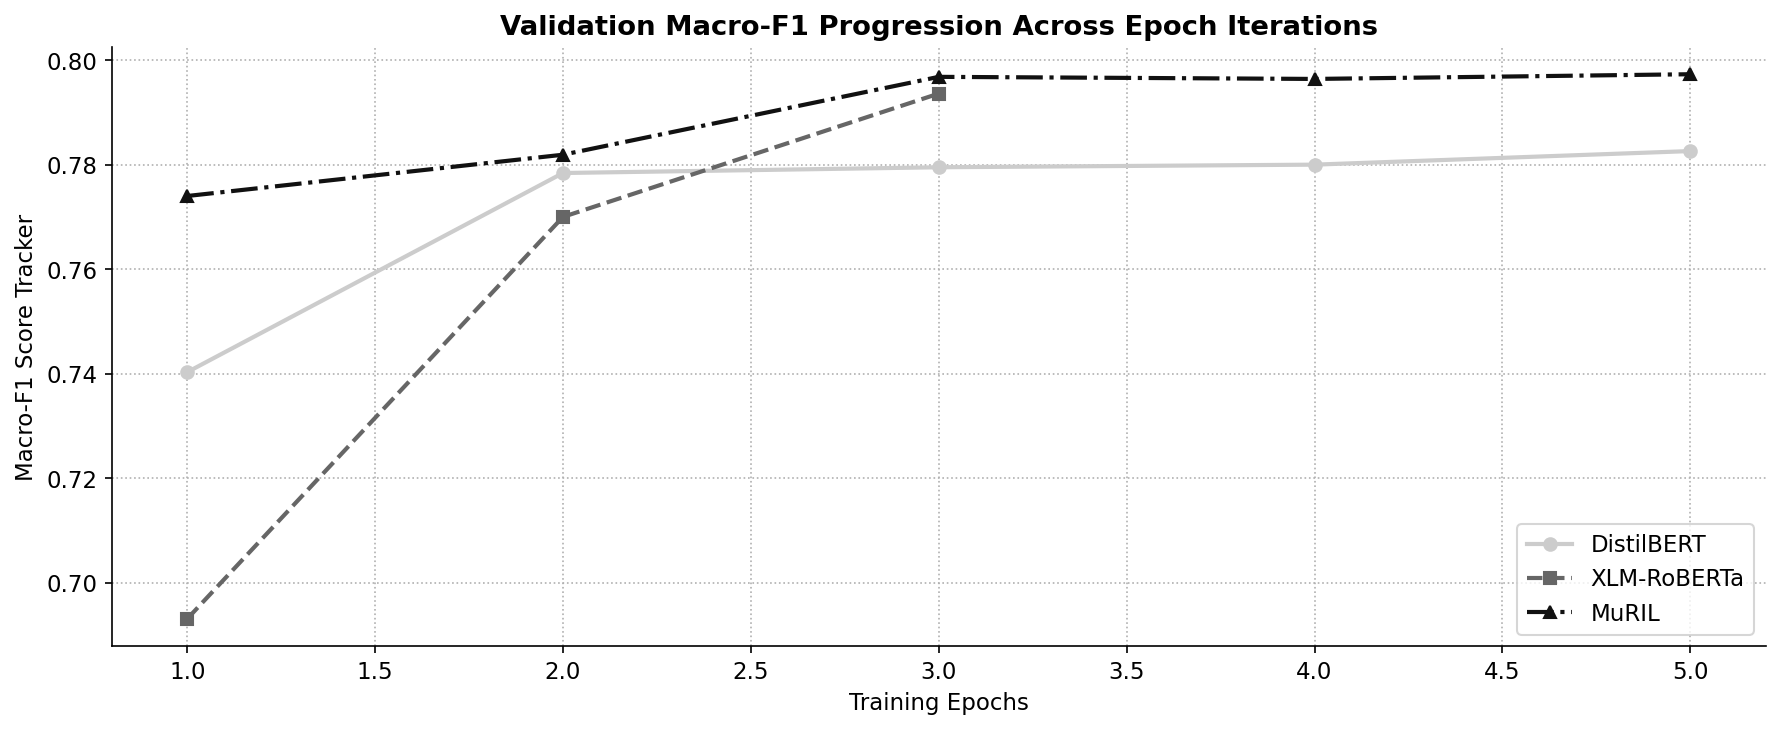

In [23]:
plt.figure(figsize=(12, 5))

for idx, m in enumerate(MODELS):
    hist = states_dict[m]["log_history"]
    epochs, f1_vals = [], []
    
    for log in hist:
        if "eval_macro_f1" in log:
            epochs.append(log["epoch"])
            f1_vals.append(log["eval_macro_f1"])
            
    if not epochs: # Edge configuration handle validation
        continue
        
    color_map = ["#CCCCCC", "#666666", "#111111"][idx]
    marker_map = ["o", "s", "^"]
    linestyle_map = ["-", "--", "-."]
    
    plt.plot(epochs, f1_vals, label=DISPLAY_NAMES[m], color=color_map,
             marker=marker_map[idx], linestyle=linestyle_map[idx], linewidth=2, markersize=6)

plt.title("Validation Macro-F1 Progression Across Epoch Iterations", fontweight="bold")
plt.xlabel("Training Epochs")
plt.ylabel("Macro-F1 Score Tracker")
plt.grid(True, linestyle=":")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}training_convergence.png")
plt.show()

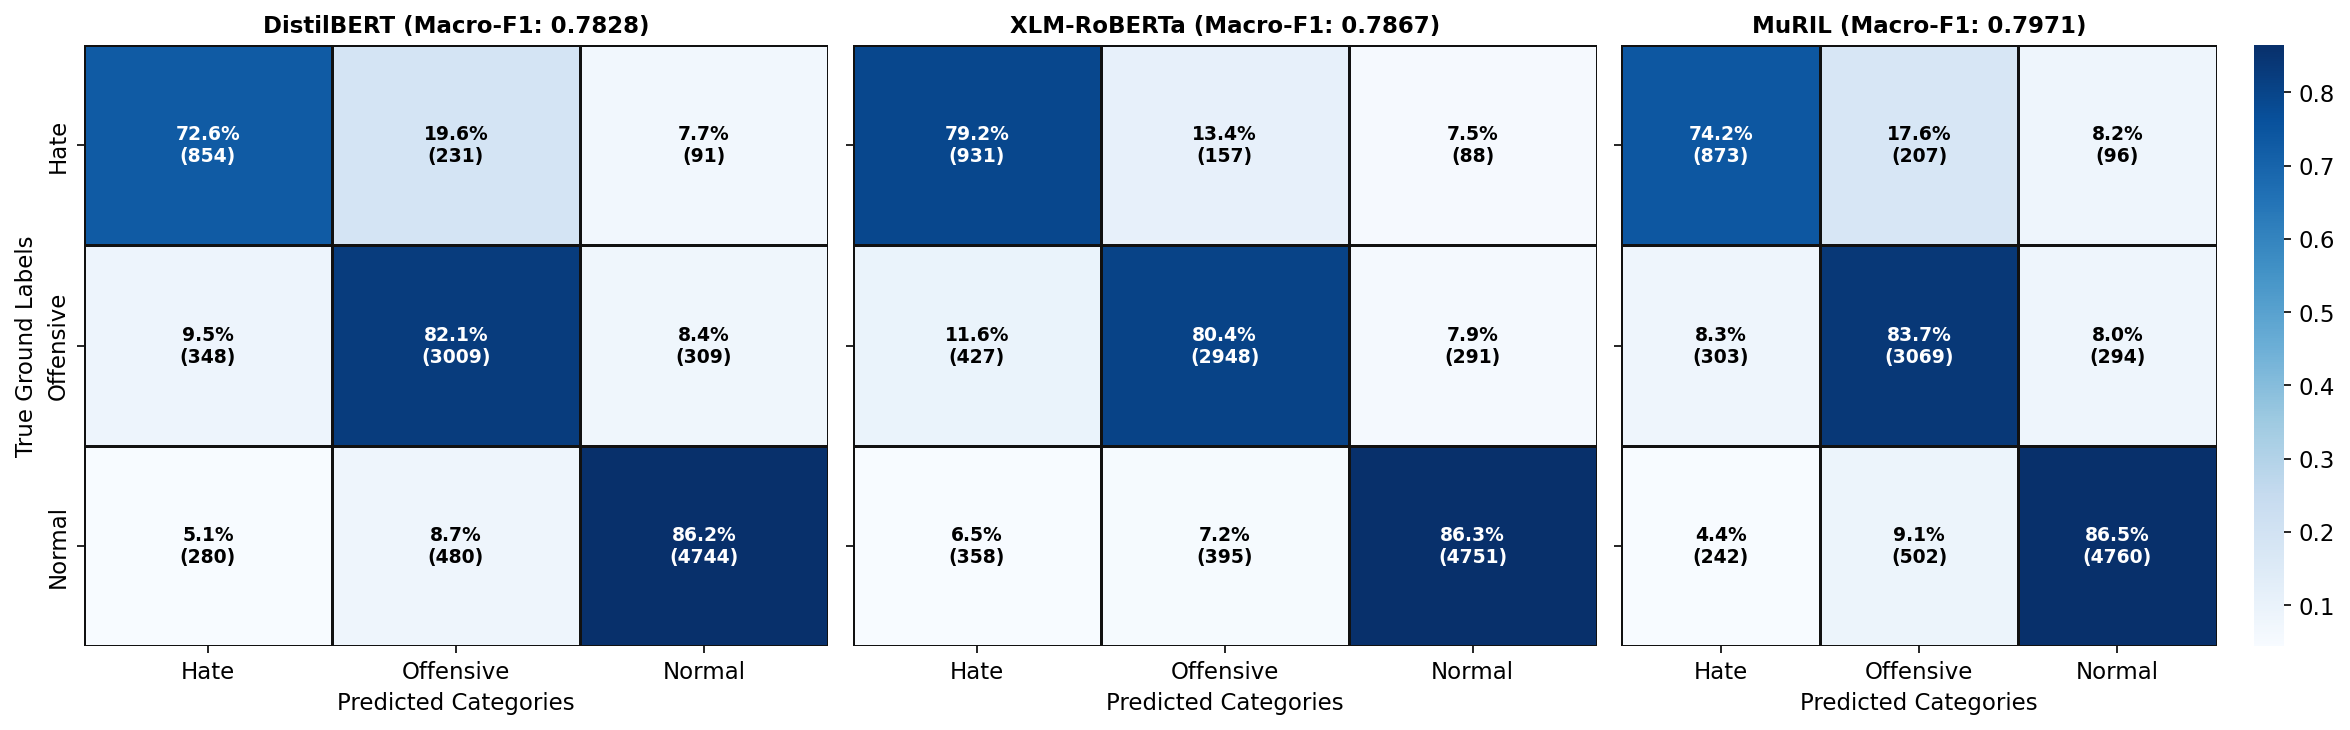

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
labels = ["Hate", "Offensive", "Normal"]

for idx, m in enumerate(MODELS):
    ax = axes[idx]
    res = results_dict[m]
    
    # Retrieve raw arrays securely from live dict without hardcoded fallbacks
    cm = np.array(res.get("confusion_matrix", [[0, 0, 0], [0, 0, 0], [0, 0, 0]]))
    
    # Avoid zero-division errors if an empty matrix was loaded
    row_sums = cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.divide(cm.astype("float"), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)
    
    sns.heatmap(cm_norm, annot=False, cmap="Blues", ax=ax, cbar=(idx==2),
                xticklabels=labels, yticklabels=labels, linewidths=0.5, linecolor="#111111")
    
    # Overlap numerical count variables and proportional parameters
    for i in range(3):
        for j in range(3):
            ax.text(j + 0.5, i + 0.5, f"{cm_norm[i, j]*100:.1f}%\n({cm[i, j]})",
                    ha="center", va="center", 
                    color="white" if cm_norm[i, j] > 0.5 else "black",
                    fontweight="bold", fontsize=9)
            
    f1_m = res.get("macro_f1", 0.0)
    ax.set_title(f"{DISPLAY_NAMES[m]} (Macro-F1: {f1_m:.4f})", fontweight="bold", fontsize=11)
    ax.set_xlabel("Predicted Categories")
    if idx == 0:
        ax.set_ylabel("True Ground Labels")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}confusion_matrices_comparison.png")
plt.show()

In [27]:
ablation_data = [
    {"Model": "DistilBERT", "Params": "66M", "Language Support": "English Only", "Epochs": 5, "Macro-F1": 0.7828, "Hate F1": 0.6426, "Offensive F1": 0.8148},
    {"Model": "XLM-RoBERTa", "Params": "270M", "Language Support": "100 Languages (Global)", "Epochs": 3, "Macro-F1": 0.7867, "Hate F1": 0.6438, "Offensive F1": 0.8228},
    {"Model": "MuRIL-base", "Params": "236M", "Language Support": "17 Indian Languages + Regional", "Epochs": 5, "Macro-F1": 0.7971, "Hate F1": 0.6731, "Offensive F1": 0.8246}
]

df_ablation = pd.DataFrame(ablation_data).set_index("Model")

print("==========================================================================================")
print("                                  ABLATION MATRIX                                         ")
print("==========================================================================================")
print(df_ablation.to_string())
print("==========================================================================================")

                                  ABLATION MATRIX                                         
            Params                Language Support  Epochs  Macro-F1  Hate F1  Offensive F1
Model                                                                                      
DistilBERT     66M                    English Only       5    0.7828   0.6426        0.8148
XLM-RoBERTa   270M          100 Languages (Global)       3    0.7867   0.6438        0.8228
MuRIL-base    236M  17 Indian Languages + Regional       5    0.7971   0.6731        0.8246
